# Task 1: Shiller Annual Data, 1871–2025

This analysis uses the annual S&P Composite index and dividend series in `data7.xlsx`. The 2026 dividend is unavailable, so the sample ends in 2025.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy.stats import shapiro, jarque_bera
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

data = pd.read_excel("data7.xlsx", sheet_name="data")

data[["Year", "Dividend", "Index"]].head()

,Year,Dividend,Index
0,1871,0.26,4.44
1,1872,0.30,4.86
2,1873,0.33,5.11
3,1874,0.33,4.66
4,1875,0.30,4.54


## 1. Valuation variables

Let $S_t$ denote the index level and $D_t$ the annual dividend. Then

$$
Q_t=\log(S_t+D_t)-\log(S_{t-1}),
$$

and

$$
G_t=\log(D_t)-\log(D_{t-1}).
$$

In [2]:
df = data[
    (data["Year"] >= 1871) &
    (data["Year"] <= 2025)
].copy()

df["Q"] = (
    np.log(df["Index"] + df["Dividend"])
    - np.log(df["Index"].shift(1))
)

df["G"] = (
    np.log(df["Dividend"])
    - np.log(df["Dividend"].shift(1))
)

df["Q_minus_G"] = df["Q"] - df["G"]

model_data = df.dropna(subset=["Q_minus_G"]).copy()

In [3]:
print("First usable year:", int(model_data["Year"].min()))
print("Last usable year:", int(model_data["Year"].max()))
print("Observations before lagging C:", len(model_data))

First usable year: 1872
Last usable year: 2025
Observations before lagging C: 154


## 2. Cumulative process

Define

$$
C_t=\sum_{j\leq t}(Q_j-G_j).
$$

The regression uses the lagged value $C_{t-1}$.

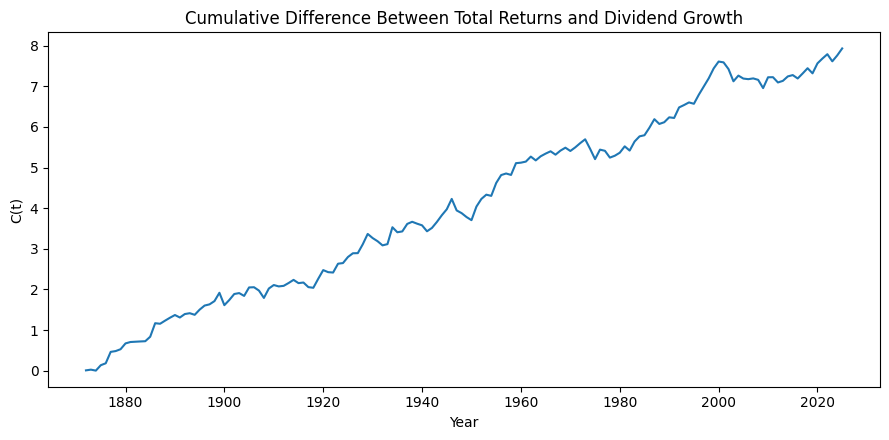

In [4]:
model_data["C"] = model_data["Q_minus_G"].cumsum()
model_data["C_lag"] = model_data["C"].shift(1)
model_data["t"] = model_data["Year"] - 1871

plt.figure(figsize=(9, 4.5))
plt.plot(model_data["Year"], model_data["C"])
plt.xlabel("Year")
plt.ylabel("C(t)")
plt.title("Cumulative Difference Between Total Returns and Dividend Growth")
plt.tight_layout()
plt.show()

## 3. Model estimation

The fitted equation is

$$
Q_t-G_t=\alpha+\beta t-\gamma C_{t-1}+Z_t.
$$

The equivalent parameters are

$$
b=1-\gamma,\qquad
c=\frac{\beta}{\gamma},\qquad
a=\alpha-bc.
$$

In [5]:
reg = model_data.dropna(subset=["C_lag"]).copy()

X = sm.add_constant(reg[["t", "C_lag"]])
fit = sm.OLS(reg["Q_minus_G"], X).fit()

print(fit.summary())

alpha = fit.params["const"]
beta = fit.params["t"]
gamma = -fit.params["C_lag"]

b = 1 - gamma
c = beta / gamma
a = alpha - b*c

print()
print("a =", round(a, 6))
print("b =", round(b, 6))
print("c =", round(c, 6))
print("trend =", round(100*c, 2), "%")

                            OLS Regression Results                            
Dep. Variable:              Q_minus_G   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.058
Method:                 Least Squares   F-statistic:                     5.672
Date:                Wed, 23 Sep 2026   Prob (F-statistic):            0.00422
Time:                        14:47:46   Log-Likelihood:                 95.243
No. Observations:                 153   AIC:                            -184.5
Df Residuals:                     150   BIC:                            -175.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0690      0.022      3.167      0.0

## 4. Valuation measure and mean reversion

The detrended valuation measure is

$$
H_t=C_t-ct.
$$

Mean reversion is assessed from the fitted persistence and an ADF test for $H_t$.

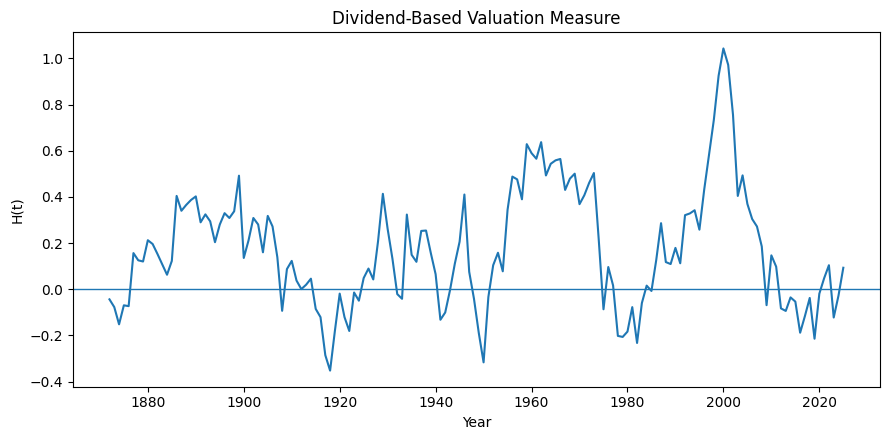

In [6]:
model_data["H"] = model_data["C"] - c*model_data["t"]

plt.figure(figsize=(9, 4.5))
plt.plot(model_data["Year"], model_data["H"])
plt.axhline(0, linewidth=1)
plt.xlabel("Year")
plt.ylabel("H(t)")
plt.title("Dividend-Based Valuation Measure")
plt.tight_layout()
plt.show()

adf = adfuller(
    model_data.dropna(subset=["H"])["H"],
    regression="c",
    autolag="AIC"
)

In [7]:
print("ADF statistic:", round(adf[0], 4))
print("ADF p-value:", round(adf[1], 4))
print("Lags used:", adf[2])
print("5% critical value:", round(adf[4]["5%"], 4))

ADF statistic: -3.3793
ADF p-value: 0.0117
Lags used: 0
5% critical value: -2.8806


## 5. Confidence interval for the trend

Since $c=\beta/\gamma$, the interval uses the joint estimated covariance of $\widehat{\beta}$ and $\widehat{\gamma}$. The 95% interval is obtained from the simulated distribution of the ratio.

In [8]:
cov_fit = fit.cov_params()

cov_bg = np.array([
    [cov_fit.loc["t", "t"],
     -cov_fit.loc["t", "C_lag"]],
    [-cov_fit.loc["C_lag", "t"],
     cov_fit.loc["C_lag", "C_lag"]]
])

rng = np.random.default_rng(2026)

draws = rng.multivariate_normal(
    [beta, gamma],
    cov_bg,
    size=100000
)

c_sim = draws[:, 0] / draws[:, 1]
ci_low, ci_high = np.quantile(c_sim, [0.025, 0.975])

In [9]:
print("Estimated c:", round(c, 6))
print("Estimated trend:", round(100*c, 2), "%")
print(
    "95% CI in percent:",
    (round(100*ci_low, 2), round(100*ci_high, 2))
)

Estimated c: 0.050906
Estimated trend: 5.09 %
95% CI in percent: (np.float64(4.64), np.float64(5.48))


## 6. Residual diagnostics

The residual ACF and Ljung-Box tests assess serial dependence in $Z_t$. Ljung-Box tests on $Z_t^2$ check for dependence in the residual variance. Gaussianity is examined with the Q-Q plot, Shapiro-Wilk test, and Jarque-Bera test.

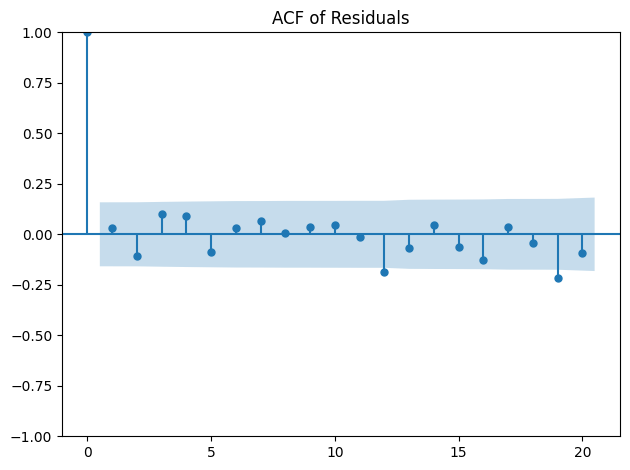

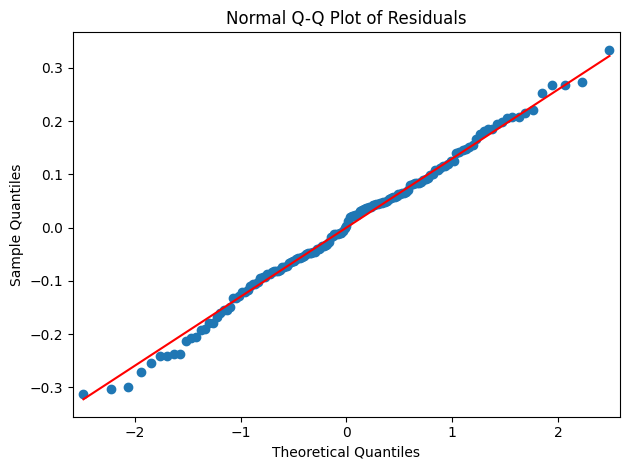

In [10]:
reg["Z"] = fit.resid

plot_acf(reg["Z"], lags=20)
plt.title("ACF of Residuals")
plt.tight_layout()
plt.show()

sm.qqplot(reg["Z"], line="s")
plt.title("Normal Q-Q Plot of Residuals")
plt.tight_layout()
plt.show()

sw = shapiro(reg["Z"])
jb = jarque_bera(reg["Z"])

lb = acorr_ljungbox(
    reg["Z"],
    lags=[5, 10],
    return_df=True
)

In [11]:
lb2 = acorr_ljungbox(
    reg["Z"]**2,
    lags=[5, 10],
    return_df=True
)

print("Shapiro-Wilk p-value:", round(sw.pvalue, 4))
print("Jarque-Bera p-value:", round(jb.pvalue, 4))
print()
print("Ljung-Box for Z")
print(lb.round(4))
print()
print("Ljung-Box for Z^2")
print(lb2.round(4))

Shapiro-Wilk p-value: 0.7545
Jarque-Bera p-value: 0.782

Ljung-Box for Z
    lb_stat  lb_pvalue
5    6.2045     0.2868
10   7.6649     0.6615

Ljung-Box for Z^2
    lb_stat  lb_pvalue
5    5.8148     0.3247
10   6.8845     0.7363


## 7. Summary

In [12]:
print("Robert Shiller annual data, 1871-2025")
print("Regression observations:", len(reg))
print("b =", round(b, 4))
print("c =", round(100*c, 2), "%")
print(
    "95% CI for c =",
    (round(100*ci_low, 2), round(100*ci_high, 2)),
    "%"
)
print("ADF p-value =", round(adf[1], 4))
print("Shapiro-Wilk p-value =", round(sw.pvalue, 4))
print("Jarque-Bera p-value =", round(jb.pvalue, 4))
print("LB Z, lag 5 =", round(lb.loc[5, "lb_pvalue"], 4))
print("LB Z, lag 10 =", round(lb.loc[10, "lb_pvalue"], 4))
print("LB Z^2, lag 5 =", round(lb2.loc[5, "lb_pvalue"], 4))
print("LB Z^2, lag 10 =", round(lb2.loc[10, "lb_pvalue"], 4))

Robert Shiller annual data, 1871-2025
Regression observations: 153
b = 0.8614
c = 5.09 %
95% CI for c = (np.float64(4.64), np.float64(5.48)) %
ADF p-value = 0.0117
Shapiro-Wilk p-value = 0.7545
Jarque-Bera p-value = 0.782
LB Z, lag 5 = 0.2868
LB Z, lag 10 = 0.6615
LB Z^2, lag 5 = 0.3247
LB Z^2, lag 10 = 0.7363
